<a href="https://colab.research.google.com/github/maalaaikaa/Intro-to-Computer-Vision/blob/main/Lab_02_Skin_Lesion_Filtering/CV_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Dataset:** HAM10000  
**Goal:** Compare three pretrained CNNs on original images and five spatial-domain filters.

This notebook is Colab-ready. Run cells from top to bottom. Change only the
settings cell first. Results, plots, confusion matrices, ROC curves, and CSV
files are saved automatically under `Lab_02_Results`.

## 1. Install and import libraries

In [ ]:
!pip -q install kagglehub seaborn scikit-learn opencv-python-headless

In [3]:
import os, gc, json, time, random, warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Reproducibility and experiment settings

Replace `MODEL_NAMES` with the best three models from Lab Activity 1 if they
are different. Use `QUICK_RUN=True` first to test the full pipeline. For the
final experiment set it to `False`.

In [4]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Improved training configuration
EPOCHS = 12
BACKBONE_LR = 2e-5
HEAD_LR = 2e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
LABEL_SMOOTHING = 0.05

# False skips completed model-filter runs; True deliberately trains them again.
FORCE_RERUN = False
GRAD_CLIP = 1.0

MODEL_NAMES = ["efficientnet_b0", "resnet50", "densenet121"]
FILTER_NAMES = ["none", "average", "gaussian", "median", "sharpening", "sobel"]

# None uses all seven HAM10000 classes.
SELECTED_CLASSES = None

# False is required for the final lab results. Turn it on only for debugging.
QUICK_RUN = False
QUICK_IMAGES_PER_CLASS = 120

# Full fine-tuning normally performs much better than training only the head.
FREEZE_BACKBONE = False
USE_WEIGHTED_LOSS = True

OUTPUT_DIR = Path("Lab_02_Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Final dataset mode:", "FULL HAM10000" if not QUICK_RUN else "QUICK TEST SUBSET")
if DEVICE.type != "cuda":
    print("Tip: Colab → Runtime → Change runtime type → T4 GPU")


Device: cuda
Final dataset mode: FULL HAM10000


## 3. Download and locate HAM10000

The code uses the public Kaggle HAM10000 package. If KaggleHub requests
authentication, upload your `kaggle.json` in Colab or add the dataset through
the Colab Kaggle integration, then rerun this cell.

In [5]:
import kagglehub

DATA_ROOT = Path(kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000"))
print("Dataset root:", DATA_ROOT)

metadata_candidates = list(DATA_ROOT.rglob("HAM10000_metadata.csv"))
if not metadata_candidates:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")
METADATA_PATH = metadata_candidates[0]

image_paths = {}
for ext in ("*.jpg", "*.jpeg", "*.png"):
    for path in DATA_ROOT.rglob(ext):
        image_paths[path.stem] = str(path)

df = pd.read_csv(METADATA_PATH)
df["path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["path"]).reset_index(drop=True)

if SELECTED_CLASSES is not None:
    df = df[df["dx"].isin(SELECTED_CLASSES)].reset_index(drop=True)

if df.empty:
    raise ValueError("No images remain. Check DATA_ROOT and SELECTED_CLASSES.")

CLASS_NAMES = sorted(df["dx"].unique().tolist())
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
df["label"] = df["dx"].map(class_to_idx)

print(f"Images found: {len(df):,}")
print("Classes:", CLASS_NAMES)
display(df.head())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset root: /kaggle/input/skin-cancer-mnist-ham10000
Images found: 10,015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2


## 4. Class distribution and optional stratified quick subset

,images
dx,
akiec,327
bcc,514
bkl,1099
df,115
mel,1113
nv,6705
vasc,142


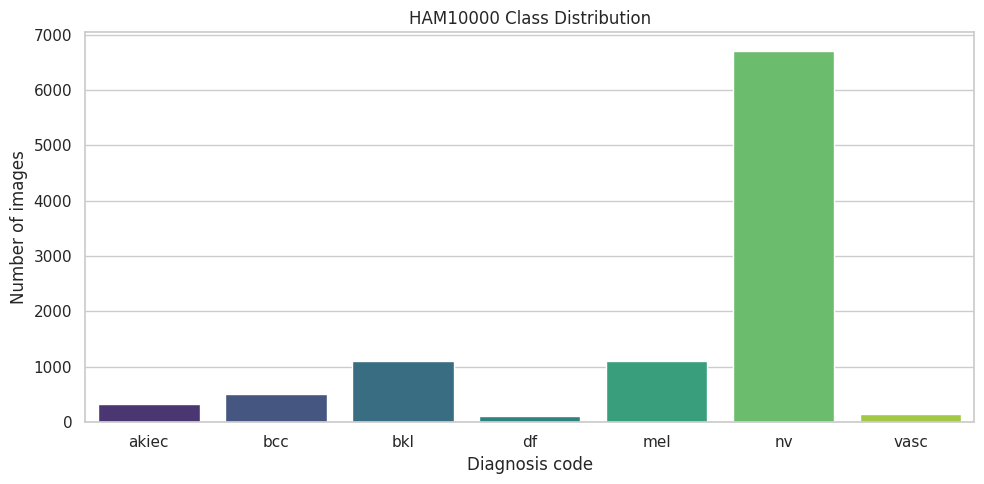

In [6]:
full_distribution = df["dx"].value_counts().reindex(CLASS_NAMES)
display(full_distribution.rename("images").to_frame())

plt.figure(figsize=(10, 5))
sns.barplot(x=full_distribution.index, y=full_distribution.values, palette="viridis")
plt.title("HAM10000 Class Distribution")
plt.xlabel("Diagnosis code")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=200)
plt.show()

if QUICK_RUN:
    sampled = []
    for _, group in df.groupby("dx"):
        sampled.append(group.sample(n=min(QUICK_IMAGES_PER_CLASS, len(group)), random_state=SEED))
    df = pd.concat(sampled).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"QUICK_RUN enabled: {len(df)} images")

## 5. Fixed train, validation, and test split

The same indices are reused for every model and filter. Stratification keeps
the class proportions approximately equal across splits.

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for part in (train_df, val_df, test_df):
    part.reset_index(drop=True, inplace=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "images": [len(train_df), len(val_df), len(test_df)]
})
display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "dataset_split.csv", index=False)

train_df[["image_id", "dx", "label", "path"]].to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df[["image_id", "dx", "label", "path"]].to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df[["image_id", "dx", "label", "path"]].to_csv(OUTPUT_DIR / "test_split.csv", index=False)

,split,images
0,train,7010
1,validation,1502
2,test,1503


## 6. Spatial-domain filters

In [8]:
def apply_filter(image_rgb, filter_name):
    """Apply one filter to an RGB uint8 NumPy image and return RGB uint8."""
    if filter_name == "none":
        result = image_rgb
    elif filter_name == "average":
        result = cv2.blur(image_rgb, (5, 5))
    elif filter_name == "gaussian":
        result = cv2.GaussianBlur(image_rgb, (5, 5), 0)
    elif filter_name == "median":
        result = cv2.medianBlur(image_rgb, 5)
    elif filter_name == "sharpening":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
        result = cv2.filter2D(image_rgb, -1, kernel)
    elif filter_name == "sobel":
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sx, sy)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        result = cv2.cvtColor(magnitude, cv2.COLOR_GRAY2RGB)
    else:
        raise ValueError(f"Unknown filter: {filter_name}")
    return np.clip(result, 0, 255).astype(np.uint8)

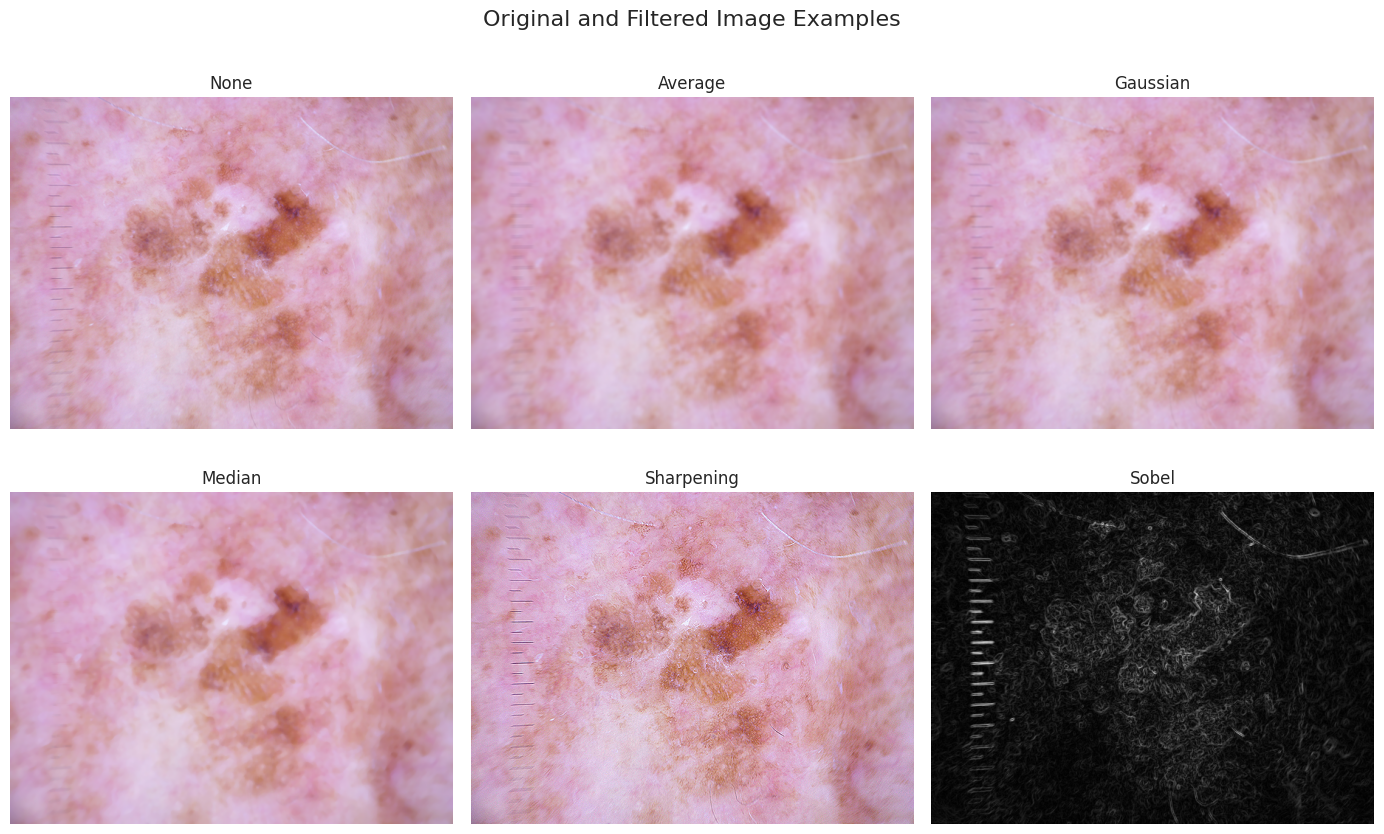

In [9]:
example_rgb = np.array(Image.open(df.iloc[0]["path"]).convert("RGB"))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, filter_name in zip(axes.ravel(), FILTER_NAMES):
    ax.imshow(apply_filter(example_rgb, filter_name))
    ax.set_title(filter_name.title())
    ax.axis("off")
plt.suptitle("Original and Filtered Image Examples", fontsize=16)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "filter_examples.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Dataset and data loaders

Augmentation is applied only to training data. Filtering occurs before
augmentation and normalization. All models use ImageNet normalization.

In [10]:
# Gentle augmentation: preserves lesion morphology better than aggressive cropping.
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE, scale=(0.90, 1.0), ratio=(0.95, 1.05)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class HAMFilterDataset(Dataset):
    def __init__(self, frame, filter_name, transform):
        self.frame = frame.reset_index(drop=True)
        self.filter_name = filter_name
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = np.array(Image.open(row["path"]).convert("RGB"))
        image = apply_filter(image, self.filter_name)
        image = Image.fromarray(image)
        return self.transform(image), int(row["label"])

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

def make_loaders(filter_name):
    train_ds = HAMFilterDataset(train_df, filter_name, train_transform)
    val_ds = HAMFilterDataset(val_df, filter_name, eval_transform)
    test_ds = HAMFilterDataset(test_df, filter_name, eval_transform)

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
    )
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        train_ds, shuffle=True, generator=generator, drop_last=False, **common
    )
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader


## 8. Load pretrained models

In [11]:
def build_model(model_name, num_classes):
    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        head = nn.Sequential(
            nn.Dropout(p=0.30),
            nn.Linear(model.classifier[1].in_features, num_classes)
        )
        model.classifier = head

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        head = nn.Sequential(
            nn.Dropout(p=0.30),
            nn.Linear(model.fc.in_features, num_classes)
        )
        model.fc = head

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        head = nn.Sequential(
            nn.Dropout(p=0.30),
            nn.Linear(model.classifier.in_features, num_classes)
        )
        model.classifier = head

    else:
        raise ValueError(
            f"Unsupported model: {model_name}. "
            "Use efficientnet_b0, resnet50, or densenet121."
        )

    if FREEZE_BACKBONE:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in head.parameters():
            parameter.requires_grad = True

    model = model.to(DEVICE)
    return model, head


In [13]:
# Square-root inverse-frequency weights reduce class imbalance without
# over-correcting as aggressively as full inverse-frequency weighting.
counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(len(CLASS_NAMES)), fill_value=1)
    .sort_index()
    .values
)
raw_weights = np.sqrt(len(train_df) / (len(CLASS_NAMES) * counts))
raw_weights = raw_weights / raw_weights.mean()
class_weights = torch.tensor(raw_weights, dtype=torch.float32, device=DEVICE)

print("Training class counts:", dict(zip(CLASS_NAMES, counts)))
print("Loss weights:", dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3))))


Training class counts: {'akiec': np.int64(229), 'bcc': np.int64(360), 'bkl': np.int64(769), 'df': np.int64(81), 'mel': np.int64(779), 'nv': np.int64(4693), 'vasc': np.int64(99)}
Loss weights: {'akiec': np.float32(1.11), 'bcc': np.float32(0.885), 'bkl': np.float32(0.606), 'df': np.float32(1.866), 'mel': np.float32(0.602), 'nv': np.float32(0.245), 'vasc': np.float32(1.688)}


## 9. Training and validation functions

In [12]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    total_loss, all_true, all_pred = 0.0, [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(logits.argmax(1).detach().cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_true, all_pred)
    epoch_macro_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    return epoch_loss, epoch_accuracy, epoch_macro_f1

def train_model(model, head, train_loader, val_loader, experiment_name):
    criterion = nn.CrossEntropyLoss(
        weight=class_weights if USE_WEIGHTED_LOSS else None,
        label_smoothing=LABEL_SMOOTHING,
    )

    head_ids = {id(parameter) for parameter in head.parameters()}
    head_parameters = [p for p in model.parameters() if id(p) in head_ids and p.requires_grad]
    backbone_parameters = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]

    parameter_groups = [{"params": head_parameters, "lr": HEAD_LR}]
    if backbone_parameters:
        parameter_groups.insert(0, {"params": backbone_parameters, "lr": BACKBONE_LR})

    optimizer = torch.optim.AdamW(parameter_groups, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-7
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = {
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": [],
        "train_macro_f1": [], "val_macro_f1": []
    }
    best_macro_f1, bad_epochs, start_epoch = -1.0, 0, 0
    best_checkpoint = OUTPUT_DIR / f"{experiment_name}_best.pt"
    resume_checkpoint = OUTPUT_DIR / f"{experiment_name}_resume.pt"

    # Continue an interrupted experiment from its latest completed epoch.
    if resume_checkpoint.exists() and not FORCE_RERUN:
        state = torch.load(resume_checkpoint, map_location=DEVICE, weights_only=False)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        history = state["history"]
        best_macro_f1 = state["best_macro_f1"]
        bad_epochs = state["bad_epochs"]
        start_epoch = state["next_epoch"]
        print(f"Resuming {experiment_name} from epoch {start_epoch + 1}.")

    for epoch in range(start_epoch, EPOCHS):
        train_loss, train_acc, train_f1 = run_epoch(
            model, train_loader, criterion, optimizer, scaler
        )
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["train_macro_f1"].append(train_f1)
        history["val_macro_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"train loss {train_loss:.4f}, acc {train_acc:.4f}, macro-F1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f}, acc {val_acc:.4f}, macro-F1 {val_f1:.4f}"
        )

        if val_f1 > best_macro_f1 + 1e-4:
            best_macro_f1 = val_f1
            bad_epochs = 0
            torch.save(model.state_dict(), best_checkpoint)
        else:
            bad_epochs += 1

        # Save after every epoch so the same cell can continue after interruption.
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),
            "history": history,
            "best_macro_f1": best_macro_f1,
            "bad_epochs": bad_epochs,
            "next_epoch": epoch + 1,
        }, resume_checkpoint)

        if bad_epochs >= PATIENCE:
            print(f"Early stopping. Best validation Macro-F1: {best_macro_f1:.4f}")
            break

    if not best_checkpoint.exists():
        raise RuntimeError(f"Best checkpoint was not created for {experiment_name}.")

    model.load_state_dict(torch.load(best_checkpoint, map_location=DEVICE, weights_only=True))
    return model, history


## 10. Evaluation, metrics, and visualizations

In [14]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for images, labels in loader:
        logits = model(images.to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        all_true.extend(labels.numpy())
        all_pred.extend(probs.argmax(1).cpu().numpy())
        all_prob.extend(probs.cpu().numpy())
    return np.asarray(all_true), np.asarray(all_pred), np.asarray(all_prob)

def calculate_metrics(y_true, y_pred, y_prob):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    try:
        result["AUC"] = roc_auc_score(
            y_true, y_prob, multi_class="ovr", average="macro",
            labels=np.arange(len(CLASS_NAMES))
        )
    except ValueError:
        result["AUC"] = np.nan
    return result

def save_history_plot(history, name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_accuracy"], marker="o", label="Train")
    axes[0].plot(epochs, history["val_accuracy"], marker="o", label="Validation")
    axes[0].set(title="Accuracy Curve", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()
    axes[1].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[1].plot(epochs, history["val_loss"], marker="o", label="Validation")
    axes[1].set(title="Loss Curve", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()
    fig.suptitle(name)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{name}_curves.png", dpi=180)
    plt.close(fig)

def save_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}_confusion_matrix.png", dpi=180)
    plt.close()

def save_roc_curves(y_true, y_prob, name):
    y_bin = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))
    plt.figure(figsize=(8, 6))
    plotted = False
    for i, cls in enumerate(CLASS_NAMES):
        if len(np.unique(y_bin[:, i])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
        plotted = True
    if plotted:
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"One-vs-Rest ROC Curves — {name}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{name}_roc.png", dpi=180)
    plt.close()

## 11. Run the 18 experiments independently

There are 18 separate execution cells: three architectures multiplied by six
image conditions. Run one cell, wait for it to finish and save, and then run the
next cell manually. Do not use **Run all** for this section. If an experiment is
interrupted, rerun the same cell and it continues from its latest completed
epoch. A completed experiment is skipped automatically.


In [15]:
# Run once. Existing CSV results are loaded automatically after a restart.
RESULTS_FILE = OUTPUT_DIR / "comparison_results.csv"
PER_CLASS_FILE = OUTPUT_DIR / "per_class_results.csv"

if RESULTS_FILE.exists():
    all_results = pd.read_csv(RESULTS_FILE).to_dict("records")
else:
    all_results = []

if PER_CLASS_FILE.exists():
    all_per_class = pd.read_csv(PER_CLASS_FILE).to_dict("records")
else:
    all_per_class = []

print(f"Loaded {len(all_results)} completed experiment(s).")
print("Completed combinations:")
for row in all_results:
    print(f"  {row['Model']} + {row['Filter']}")


Loaded 0 completed experiment(s).
Completed combinations:


In [16]:
def run_single_experiment(model_name, filter_name):
    global all_results, all_per_class

    if model_name not in MODEL_NAMES:
        raise ValueError(f"Unknown model. Choose one of {MODEL_NAMES}")
    if filter_name not in FILTER_NAMES:
        raise ValueError(f"Unknown filter. Choose one of {FILTER_NAMES}")

    readable_filter = "No Filter" if filter_name == "none" else filter_name.title()
    experiment = f"{model_name}_{filter_name}"

    already_done = any(
        row.get("Model") == model_name and row.get("Filter") == readable_filter
        for row in all_results
    )
    if already_done and not FORCE_RERUN:
        print(f"SKIPPED: {model_name} + {readable_filter} is already completed.")
        return pd.DataFrame([
            row for row in all_results
            if row.get("Model") == model_name and row.get("Filter") == readable_filter
        ])

    # Remove the old row only when the user deliberately requests a rerun.
    all_results = [
        row for row in all_results
        if not (row.get("Model") == model_name and row.get("Filter") == readable_filter)
    ]
    all_per_class = [
        row for row in all_per_class
        if not (row.get("Model") == model_name and row.get("Filter") == readable_filter)
    ]

    if FORCE_RERUN:
        for suffix in ("best.pt", "resume.pt"):
            checkpoint = OUTPUT_DIR / f"{experiment}_{suffix}"
            if checkpoint.exists():
                checkpoint.unlink()

    print("\n" + "=" * 80)
    print(f"ONE EXPERIMENT ONLY: {model_name} + {readable_filter}")
    print("=" * 80)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    train_loader = val_loader = test_loader = model = head = None
    try:
        train_loader, val_loader, test_loader = make_loaders(filter_name)
        model, head = build_model(model_name, len(CLASS_NAMES))
        start = time.time()

        model, history = train_model(
            model, head, train_loader, val_loader, experiment
        )
        y_true, y_pred, y_prob = predict(model, test_loader)
        metrics = calculate_metrics(y_true, y_pred, y_prob)
        metrics.update({
            "Model": model_name,
            "Filter": readable_filter,
            "Training Time (min)": (time.time() - start) / 60,
        })
        all_results.append(metrics)

        report = classification_report(
            y_true, y_pred,
            labels=np.arange(len(CLASS_NAMES)),
            target_names=CLASS_NAMES,
            output_dict=True, zero_division=0,
        )
        for cls in CLASS_NAMES:
            all_per_class.append({
                "Model": model_name, "Filter": readable_filter, "Class": cls,
                "Precision": report[cls]["precision"],
                "Recall": report[cls]["recall"],
                "F1-score": report[cls]["f1-score"],
                "Support": report[cls]["support"],
            })

        save_history_plot(history, experiment)
        save_confusion_matrix(y_true, y_pred, experiment)
        save_roc_curves(y_true, y_prob, experiment)

        # Save immediately; completed work survives later-cell failures.
        pd.DataFrame(all_results).to_csv(RESULTS_FILE, index=False)
        pd.DataFrame(all_per_class).to_csv(PER_CLASS_FILE, index=False)

        print("\nCOMPLETED AND SAVED")
        print(f"Model:             {model_name}")
        print(f"Filter:            {readable_filter}")
        print(f"Accuracy:          {metrics['Accuracy'] * 100:.2f}%")
        print(f"Macro-F1:          {metrics['Macro-F1'] * 100:.2f}%")
        print(f"Balanced Accuracy: {metrics['Balanced Accuracy'] * 100:.2f}%")
        print(f"AUC:               {metrics['AUC'] * 100:.2f}%")
        return pd.DataFrame([metrics])

    finally:
        del train_loader, val_loader, test_loader, model, head
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


### EfficientNet B0 independent experiments

Run only one cell at a time. Each cell trains one filter condition and saves it immediately.


In [ ]:
# EfficientNet B0 — No Filter
efficientnet_b0_none_result = run_single_experiment("efficientnet_b0", "none")
display(efficientnet_b0_none_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + No Filter
Resuming efficientnet_b0_none from epoch 5.
Epoch 05/12 | train loss 1.1144, acc 0.8067, macro-F1 0.6846 | val loss 1.1298, acc 0.8103, macro-F1 0.6757
Epoch 06/12 | train loss 1.0449, acc 0.8291, macro-F1 0.7250 | val loss 1.1130, acc 0.8189, macro-F1 0.7063
Epoch 07/12 | train loss 1.0114, acc 0.8392, macro-F1 0.7527 | val loss 1.0799, acc 0.8089, macro-F1 0.6823
Epoch 08/12 | train loss 0.9926, acc 0.8414, macro-F1 0.7585 | val loss 1.0824, acc 0.8222, macro-F1 0.6972
Epoch 09/12 | train loss 1.0627, acc 0.8203, macro-F1 0.7059 | val loss 1.0673, acc 0.8096, macro-F1 0.7005
Epoch 10/12 | train loss 1.0601, acc 0.8168, macro-F1 0.7073 | val loss 1.0814, acc 0.8236, macro-F1 0.6937
Early stopping. Best validation Macro-F1: 0.7063

COMPLETED AND SAVED
Model:             efficientnet_b0
Filter:            No Filter
Accuracy:          80.37%
Macro-F1:          64.79%
Balanced Accuracy: 63.87%
AUC:               95.18%


,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8037,0.8148,0.8037,0.8072,0.6479,0.6387,0.9518,efficientnet_b0,No Filter,10.8543


In [ ]:
# EfficientNet B0 — Average Filter
efficientnet_b0_average_result = run_single_experiment("efficientnet_b0", "average")
display(efficientnet_b0_average_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + Average
Epoch 01/12 | train loss 1.7028, acc 0.6628, macro-F1 0.2823 | val loss 1.5331, acc 0.6917, macro-F1 0.4453
Epoch 02/12 | train loss 1.4205, acc 0.7330, macro-F1 0.4875 | val loss 1.3398, acc 0.7417, macro-F1 0.5107
Epoch 03/12 | train loss 1.2941, acc 0.7502, macro-F1 0.5388 | val loss 1.2419, acc 0.7550, macro-F1 0.5366
Epoch 04/12 | train loss 1.2233, acc 0.7670, macro-F1 0.5937 | val loss 1.1911, acc 0.7836, macro-F1 0.6201
Epoch 05/12 | train loss 1.1691, acc 0.7857, macro-F1 0.6301 | val loss 1.1540, acc 0.7823, macro-F1 0.6387
Epoch 06/12 | train loss 1.1374, acc 0.7942, macro-F1 0.6537 | val loss 1.1252, acc 0.7963, macro-F1 0.6466
Epoch 07/12 | train loss 1.1183, acc 0.7966, macro-F1 0.6717 | val loss 1.1070, acc 0.8083, macro-F1 0.6833
Epoch 08/12 | train loss 1.0955, acc 0.8047, macro-F1 0.6791 | val loss 1.1045, acc 0.8009, macro-F1 0.6752
Epoch 09/12 | train loss 1.0852, acc 0.8078, macro-F1 0.6820 | val loss 1.0951, acc 0.80

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.7984,0.8142,0.7984,0.8027,0.6411,0.6607,0.9426,efficientnet_b0,Average,22.1785


In [ ]:
# EfficientNet B0 — Gaussian Filter
efficientnet_b0_gaussian_result = run_single_experiment("efficientnet_b0", "gaussian")
display(efficientnet_b0_gaussian_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + Gaussian
Epoch 01/12 | train loss 1.6973, acc 0.6642, macro-F1 0.2791 | val loss 1.5183, acc 0.7051, macro-F1 0.4414
Epoch 02/12 | train loss 1.4157, acc 0.7338, macro-F1 0.4931 | val loss 1.3242, acc 0.7457, macro-F1 0.5383
Epoch 03/12 | train loss 1.2848, acc 0.7556, macro-F1 0.5536 | val loss 1.2221, acc 0.7710, macro-F1 0.5629
Epoch 04/12 | train loss 1.2166, acc 0.7723, macro-F1 0.5973 | val loss 1.1724, acc 0.7856, macro-F1 0.6223
Epoch 05/12 | train loss 1.1598, acc 0.7912, macro-F1 0.6381 | val loss 1.1323, acc 0.7963, macro-F1 0.6536
Epoch 06/12 | train loss 1.1299, acc 0.7933, macro-F1 0.6508 | val loss 1.1136, acc 0.8089, macro-F1 0.6749
Epoch 07/12 | train loss 1.1089, acc 0.8010, macro-F1 0.6830 | val loss 1.0871, acc 0.8129, macro-F1 0.6804
Epoch 08/12 | train loss 1.0842, acc 0.8067, macro-F1 0.6895 | val loss 1.0808, acc 0.8103, macro-F1 0.6935
Epoch 09/12 | train loss 1.0718, acc 0.8127, macro-F1 0.6922 | val loss 1.0714, acc 0.8

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8031,0.8148,0.8031,0.8055,0.6506,0.6695,0.9462,efficientnet_b0,Gaussian,22.5567


In [ ]:
# EfficientNet B0 — Median Filter
efficientnet_b0_median_result = run_single_experiment("efficientnet_b0", "median")
display(efficientnet_b0_median_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + Median
Epoch 01/12 | train loss 1.6997, acc 0.6642, macro-F1 0.2783 | val loss 1.5220, acc 0.6991, macro-F1 0.4575
Epoch 02/12 | train loss 1.4140, acc 0.7337, macro-F1 0.4949 | val loss 1.3283, acc 0.7344, macro-F1 0.5071
Epoch 03/12 | train loss 1.2869, acc 0.7508, macro-F1 0.5388 | val loss 1.2358, acc 0.7597, macro-F1 0.5317
Epoch 04/12 | train loss 1.2211, acc 0.7690, macro-F1 0.6025 | val loss 1.1849, acc 0.7876, macro-F1 0.6304
Epoch 05/12 | train loss 1.1666, acc 0.7883, macro-F1 0.6413 | val loss 1.1494, acc 0.7836, macro-F1 0.6452
Epoch 06/12 | train loss 1.1328, acc 0.7939, macro-F1 0.6518 | val loss 1.1182, acc 0.8049, macro-F1 0.6669
Epoch 07/12 | train loss 1.1131, acc 0.7986, macro-F1 0.6811 | val loss 1.1065, acc 0.8142, macro-F1 0.6799
Epoch 08/12 | train loss 1.0896, acc 0.8051, macro-F1 0.6792 | val loss 1.1001, acc 0.8049, macro-F1 0.6766
Epoch 09/12 | train loss 1.0789, acc 0.8114, macro-F1 0.6870 | val loss 1.0900, acc 0.809

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.7971,0.8163,0.7971,0.8024,0.6648,0.6919,0.9392,efficientnet_b0,Median,24.1299


In [ ]:
# EfficientNet B0 — Sharpening Filter
efficientnet_b0_sharpening_result = run_single_experiment("efficientnet_b0", "sharpening")
display(efficientnet_b0_sharpening_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + Sharpening
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 223MB/s]


Epoch 01/12 | train loss 1.6917, acc 0.6645, macro-F1 0.2923 | val loss 1.5085, acc 0.7004, macro-F1 0.3984
Epoch 02/12 | train loss 1.3995, acc 0.7379, macro-F1 0.5040 | val loss 1.3515, acc 0.7437, macro-F1 0.5202
Epoch 03/12 | train loss 1.2709, acc 0.7660, macro-F1 0.5747 | val loss 1.2392, acc 0.7570, macro-F1 0.5548
Epoch 04/12 | train loss 1.1977, acc 0.7757, macro-F1 0.6083 | val loss 1.2138, acc 0.7856, macro-F1 0.6254
Epoch 05/12 | train loss 1.1400, acc 0.7959, macro-F1 0.6566 | val loss 1.1537, acc 0.7810, macro-F1 0.6344
Epoch 06/12 | train loss 1.1073, acc 0.8029, macro-F1 0.6785 | val loss 1.1813, acc 0.8009, macro-F1 0.6374
Epoch 07/12 | train loss 1.0814, acc 0.8127, macro-F1 0.6991 | val loss 1.1271, acc 0.7969, macro-F1 0.6449
Epoch 08/12 | train loss 1.0642, acc 0.8164, macro-F1 0.7061 | val loss 1.1357, acc 0.7956, macro-F1 0.6496
Epoch 09/12 | train loss 1.0468, acc 0.8198, macro-F1 0.7144 | val loss 1.1194, acc 0.8023, macro-F1 0.6464
Epoch 10/12 | train loss 1.0

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8137,0.8289,0.8137,0.8154,0.6682,0.6557,0.9539,efficientnet_b0,Sharpening,24.2615


In [ ]:
# EfficientNet B0 — Sobel Filter
efficientnet_b0_sobel_result = run_single_experiment("efficientnet_b0", "sobel")
display(efficientnet_b0_sobel_result.round(4))



ONE EXPERIMENT ONLY: efficientnet_b0 + Sobel
Epoch 01/12 | train loss 1.8178, acc 0.6231, macro-F1 0.1996 | val loss 1.7337, acc 0.6718, macro-F1 0.2256
Epoch 02/12 | train loss 1.6605, acc 0.6631, macro-F1 0.3234 | val loss 1.6829, acc 0.6804, macro-F1 0.2572
Epoch 03/12 | train loss 1.5801, acc 0.6673, macro-F1 0.3637 | val loss 1.6289, acc 0.6678, macro-F1 0.2790
Epoch 04/12 | train loss 1.5398, acc 0.6786, macro-F1 0.3702 | val loss 1.6904, acc 0.6631, macro-F1 0.2707
Epoch 05/12 | train loss 1.5087, acc 0.6793, macro-F1 0.3815 | val loss 1.6231, acc 0.6798, macro-F1 0.2995
Epoch 06/12 | train loss 1.4733, acc 0.6960, macro-F1 0.4232 | val loss 1.5964, acc 0.6844, macro-F1 0.3186
Epoch 07/12 | train loss 1.4452, acc 0.6987, macro-F1 0.4336 | val loss 1.6577, acc 0.6671, macro-F1 0.3015
Epoch 08/12 | train loss 1.4361, acc 0.7049, macro-F1 0.4444 | val loss 1.6107, acc 0.6651, macro-F1 0.3054
Epoch 09/12 | train loss 1.4252, acc 0.7064, macro-F1 0.4412 | val loss 1.6226, acc 0.6671

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.678,0.6449,0.678,0.64,0.3116,0.3425,0.8456,efficientnet_b0,Sobel,20.5513


### ResNet50 independent experiments

Run only one cell at a time. Each cell trains one filter condition and saves it immediately.


In [ ]:
# ResNet50 — No Filter
resnet50_none_result = run_single_experiment("resnet50", "none")
display(resnet50_none_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + No Filter
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


Epoch 01/12 | train loss 1.6643, acc 0.6775, macro-F1 0.2644 | val loss 1.4350, acc 0.7437, macro-F1 0.4969
Epoch 02/12 | train loss 1.3300, acc 0.7499, macro-F1 0.5425 | val loss 1.2127, acc 0.7969, macro-F1 0.5982
Epoch 03/12 | train loss 1.1780, acc 0.7890, macro-F1 0.6367 | val loss 1.1303, acc 0.8176, macro-F1 0.6689
Epoch 04/12 | train loss 1.0934, acc 0.8083, macro-F1 0.6843 | val loss 1.0966, acc 0.8336, macro-F1 0.7095
Epoch 05/12 | train loss 1.0345, acc 0.8287, macro-F1 0.7301 | val loss 1.0534, acc 0.8296, macro-F1 0.7101
Epoch 06/12 | train loss 0.9933, acc 0.8358, macro-F1 0.7400 | val loss 1.0516, acc 0.8342, macro-F1 0.7250
Epoch 07/12 | train loss 0.9612, acc 0.8435, macro-F1 0.7623 | val loss 1.0513, acc 0.8429, macro-F1 0.7139
Epoch 08/12 | train loss 0.9243, acc 0.8598, macro-F1 0.7892 | val loss 1.0223, acc 0.8429, macro-F1 0.7292
Epoch 09/12 | train loss 0.9102, acc 0.8672, macro-F1 0.8082 | val loss 1.0135, acc 0.8402, macro-F1 0.7350
Epoch 10/12 | train loss 0.8

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8303,0.8369,0.8303,0.8328,0.7301,0.7443,0.9634,resnet50,No Filter,24.2729


In [ ]:
# ResNet50 — Average Filter
resnet50_average_result = run_single_experiment("resnet50", "average")
display(resnet50_average_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + Average
Epoch 01/12 | train loss 1.6678, acc 0.6750, macro-F1 0.2624 | val loss 1.4516, acc 0.7383, macro-F1 0.5036
Epoch 02/12 | train loss 1.3339, acc 0.7466, macro-F1 0.5306 | val loss 1.2365, acc 0.7983, macro-F1 0.6374
Epoch 03/12 | train loss 1.1920, acc 0.7816, macro-F1 0.6334 | val loss 1.1645, acc 0.7929, macro-F1 0.6397
Epoch 04/12 | train loss 1.1152, acc 0.7999, macro-F1 0.6647 | val loss 1.1032, acc 0.8262, macro-F1 0.6938
Epoch 05/12 | train loss 1.0524, acc 0.8201, macro-F1 0.7149 | val loss 1.0836, acc 0.8262, macro-F1 0.6955
Epoch 06/12 | train loss 1.0054, acc 0.8357, macro-F1 0.7432 | val loss 1.0645, acc 0.8169, macro-F1 0.7032
Epoch 07/12 | train loss 0.9770, acc 0.8438, macro-F1 0.7643 | val loss 1.0642, acc 0.8382, macro-F1 0.7039
Epoch 08/12 | train loss 0.9503, acc 0.8545, macro-F1 0.7809 | val loss 1.0452, acc 0.8302, macro-F1 0.7046
Epoch 09/12 | train loss 0.9312, acc 0.8585, macro-F1 0.7897 | val loss 1.0431, acc 0.8262, mac

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8237,0.8296,0.8237,0.8259,0.707,0.7412,0.9578,resnet50,Average,25.5827


In [ ]:
# ResNet50 — Gaussian Filter
resnet50_gaussian_result = run_single_experiment("resnet50", "gaussian")
display(resnet50_gaussian_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + Gaussian
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Epoch 01/12 | train loss 1.6648, acc 0.6779, macro-F1 0.2735 | val loss 1.4434, acc 0.7490, macro-F1 0.4973
Epoch 02/12 | train loss 1.3331, acc 0.7501, macro-F1 0.5263 | val loss 1.2321, acc 0.7896, macro-F1 0.5832
Epoch 03/12 | train loss 1.1820, acc 0.7819, macro-F1 0.6251 | val loss 1.1474, acc 0.8083, macro-F1 0.6576
Epoch 04/12 | train loss 1.1016, acc 0.8076, macro-F1 0.6853 | val loss 1.0947, acc 0.8356, macro-F1 0.7121
Epoch 05/12 | train loss 1.0475, acc 0.8207, macro-F1 0.7158 | val loss 1.0685, acc 0.8302, macro-F1 0.7065
Epoch 06/12 | train loss 0.9941, acc 0.8355, macro-F1 0.7431 | val loss 1.0518, acc 0.8322, macro-F1 0.7186
Epoch 07/12 | train loss 0.9594, acc 0.8472, macro-F1 0.7717 | val loss 1.0529, acc 0.8336, macro-F1 0.7026
Epoch 08/12 | train loss 0.9345, acc 0.8563, macro-F1 0.7849 | val loss 1.0291, acc 0.8455, macro-F1 0.7303
Epoch 09/12 | train loss 0.9176, acc 0.8653, macro-F1 0.7973 | val loss 1.0194, acc 0.8316, macro-F1 0.7054
Epoch 10/12 | train loss 0.9

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.827,0.834,0.827,0.8296,0.7033,0.7035,0.9623,resnet50,Gaussian,24.733


In [15]:
# ResNet50 — Median Filter
resnet50_median_result = run_single_experiment("resnet50", "median")
display(resnet50_median_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + Median
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Epoch 01/12 | train loss 1.6713, acc 0.6749, macro-F1 0.2468 | val loss 1.4516, acc 0.7250, macro-F1 0.4542
Epoch 02/12 | train loss 1.3409, acc 0.7475, macro-F1 0.5335 | val loss 1.2317, acc 0.8003, macro-F1 0.5779
Epoch 03/12 | train loss 1.1879, acc 0.7826, macro-F1 0.6308 | val loss 1.1771, acc 0.7889, macro-F1 0.6221
Epoch 04/12 | train loss 1.1075, acc 0.8014, macro-F1 0.6685 | val loss 1.1110, acc 0.8216, macro-F1 0.6994
Epoch 05/12 | train loss 1.0531, acc 0.8193, macro-F1 0.7111 | val loss 1.0934, acc 0.8156, macro-F1 0.6812
Epoch 06/12 | train loss 1.0010, acc 0.8365, macro-F1 0.7493 | val loss 1.0708, acc 0.8182, macro-F1 0.6934
Epoch 07/12 | train loss 0.9720, acc 0.8434, macro-F1 0.7663 | val loss 1.0880, acc 0.8262, macro-F1 0.6913
Epoch 08/12 | train loss 0.9463, acc 0.8565, macro-F1 0.7868 | val loss 1.0505, acc 0.8395, macro-F1 0.7272
Epoch 09/12 | train loss 0.9296, acc 0.8563, macro-F1 0.7866 | val loss 1.0371, acc 0.8289, macro-F1 0.7255
Epoch 10/12 | train loss 0.9

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8244,0.833,0.8244,0.8273,0.7289,0.7519,0.9612,resnet50,Median,25.1119


In [16]:
# ResNet50 — Sharpening Filter
resnet50_sharpening_result = run_single_experiment("resnet50", "sharpening")
display(resnet50_sharpening_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + Sharpening
Epoch 01/12 | train loss 1.6610, acc 0.6799, macro-F1 0.2710 | val loss 1.4433, acc 0.7304, macro-F1 0.4320
Epoch 02/12 | train loss 1.3190, acc 0.7561, macro-F1 0.5479 | val loss 1.2629, acc 0.7756, macro-F1 0.5555
Epoch 03/12 | train loss 1.1606, acc 0.7909, macro-F1 0.6465 | val loss 1.1869, acc 0.7956, macro-F1 0.6445
Epoch 04/12 | train loss 1.0768, acc 0.8133, macro-F1 0.6942 | val loss 1.1492, acc 0.8116, macro-F1 0.6914
Epoch 05/12 | train loss 1.0227, acc 0.8311, macro-F1 0.7259 | val loss 1.0793, acc 0.8216, macro-F1 0.6966
Epoch 06/12 | train loss 0.9777, acc 0.8449, macro-F1 0.7557 | val loss 1.1071, acc 0.8242, macro-F1 0.6927
Epoch 07/12 | train loss 0.9352, acc 0.8575, macro-F1 0.7839 | val loss 1.1060, acc 0.8249, macro-F1 0.6952
Epoch 08/12 | train loss 0.9014, acc 0.8708, macro-F1 0.8165 | val loss 1.1128, acc 0.8269, macro-F1 0.6918
Epoch 09/12 | train loss 0.8884, acc 0.8775, macro-F1 0.8165 | val loss 1.0888, acc 0.8176, 

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.7957,0.8292,0.7957,0.8054,0.7011,0.6865,0.9453,resnet50,Sharpening,17.2229


In [17]:
# ResNet50 — Sobel Filter
resnet50_sobel_result = run_single_experiment("resnet50", "sobel")
display(resnet50_sobel_result.round(4))



ONE EXPERIMENT ONLY: resnet50 + Sobel
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Epoch 01/12 | train loss 1.8344, acc 0.6421, macro-F1 0.1544 | val loss 1.7224, acc 0.6711, macro-F1 0.2059
Epoch 02/12 | train loss 1.6753, acc 0.6669, macro-F1 0.2661 | val loss 1.6561, acc 0.6891, macro-F1 0.2498
Epoch 03/12 | train loss 1.5884, acc 0.6666, macro-F1 0.3356 | val loss 1.6089, acc 0.6778, macro-F1 0.2870
Epoch 04/12 | train loss 1.5201, acc 0.6829, macro-F1 0.3729 | val loss 1.6106, acc 0.6937, macro-F1 0.3227
Epoch 05/12 | train loss 1.4793, acc 0.6914, macro-F1 0.4150 | val loss 1.5772, acc 0.6984, macro-F1 0.3310
Epoch 06/12 | train loss 1.4440, acc 0.7014, macro-F1 0.4439 | val loss 1.5028, acc 0.6971, macro-F1 0.3664
Epoch 07/12 | train loss 1.4232, acc 0.7088, macro-F1 0.4663 | val loss 1.6109, acc 0.6911, macro-F1 0.3164
Epoch 08/12 | train loss 1.3904, acc 0.7178, macro-F1 0.4760 | val loss 1.5521, acc 0.6984, macro-F1 0.3517
Epoch 09/12 | train loss 1.3777, acc 0.7208, macro-F1 0.4882 | val loss 1.5648, acc 0.6931, macro-F1 0.3411
Epoch 10/12 | train loss 1.3

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.682,0.6602,0.682,0.6646,0.3528,0.3847,0.846,resnet50,Sobel,21.7202


### DenseNet121 independent experiments

Run only one cell at a time. Each cell trains one filter condition and saves it immediately.


In [21]:
# DenseNet121 — No Filter
densenet121_none_result = run_single_experiment("densenet121", "none")
display(densenet121_none_result.round(4))



ONE EXPERIMENT ONLY: densenet121 + No Filter
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 182MB/s]


Epoch 01/12 | train loss 1.6030, acc 0.6655, macro-F1 0.3510 | val loss 1.3118, acc 0.7364, macro-F1 0.5641
Epoch 02/12 | train loss 1.2856, acc 0.7536, macro-F1 0.5569 | val loss 1.1349, acc 0.7983, macro-F1 0.6796
Epoch 03/12 | train loss 1.1630, acc 0.7886, macro-F1 0.6496 | val loss 1.0709, acc 0.8269, macro-F1 0.7071
Epoch 04/12 | train loss 1.1125, acc 0.8034, macro-F1 0.6718 | val loss 1.0411, acc 0.8356, macro-F1 0.7078
Epoch 05/12 | train loss 1.0680, acc 0.8165, macro-F1 0.6995 | val loss 0.9951, acc 0.8342, macro-F1 0.7512
Epoch 06/12 | train loss 1.0149, acc 0.8304, macro-F1 0.7357 | val loss 0.9951, acc 0.8415, macro-F1 0.7636
Epoch 07/12 | train loss 0.9935, acc 0.8412, macro-F1 0.7643 | val loss 0.9768, acc 0.8515, macro-F1 0.7644
Epoch 08/12 | train loss 0.9646, acc 0.8462, macro-F1 0.7673 | val loss 0.9570, acc 0.8489, macro-F1 0.7667
Epoch 09/12 | train loss 0.9566, acc 0.8544, macro-F1 0.7809 | val loss 0.9485, acc 0.8495, macro-F1 0.7796
Epoch 10/12 | train loss 0.9

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.851,0.8555,0.851,0.8522,0.7375,0.759,0.9635,densenet121,No Filter,23.6079


In [22]:
# DenseNet121 — Average Filter
densenet121_average_result = run_single_experiment("densenet121", "average")
display(densenet121_average_result.round(4))



ONE EXPERIMENT ONLY: densenet121 + Average
Epoch 01/12 | train loss 1.5988, acc 0.6631, macro-F1 0.3461 | val loss 1.3190, acc 0.7297, macro-F1 0.5401
Epoch 02/12 | train loss 1.2946, acc 0.7462, macro-F1 0.5459 | val loss 1.1509, acc 0.7949, macro-F1 0.6619
Epoch 03/12 | train loss 1.1736, acc 0.7773, macro-F1 0.6331 | val loss 1.0933, acc 0.7956, macro-F1 0.6382
Epoch 04/12 | train loss 1.1241, acc 0.7946, macro-F1 0.6615 | val loss 1.0731, acc 0.8176, macro-F1 0.6672
Epoch 05/12 | train loss 1.0786, acc 0.8117, macro-F1 0.6922 | val loss 1.0338, acc 0.8083, macro-F1 0.6929
Epoch 06/12 | train loss 1.0254, acc 0.8245, macro-F1 0.7262 | val loss 1.0028, acc 0.8336, macro-F1 0.7518
Epoch 07/12 | train loss 1.0060, acc 0.8312, macro-F1 0.7465 | val loss 1.0037, acc 0.8389, macro-F1 0.7362
Epoch 08/12 | train loss 0.9780, acc 0.8397, macro-F1 0.7609 | val loss 0.9788, acc 0.8362, macro-F1 0.7537
Epoch 09/12 | train loss 0.9678, acc 0.8526, macro-F1 0.7762 | val loss 0.9777, acc 0.8316, 

,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Model,Filter,Training Time (min)
0,0.8463,0.8516,0.8463,0.8474,0.7375,0.7689,0.9579,densenet121,Average,24.4045


In [ ]:
# DenseNet121 — Gaussian Filter
densenet121_gaussian_result = run_single_experiment("densenet121", "gaussian")
display(densenet121_gaussian_result.round(4))



ONE EXPERIMENT ONLY: densenet121 + Gaussian
Epoch 01/12 | train loss 1.6009, acc 0.6558, macro-F1 0.3349 | val loss 1.3234, acc 0.7390, macro-F1 0.5559
Epoch 02/12 | train loss 1.2896, acc 0.7515, macro-F1 0.5506 | val loss 1.1465, acc 0.7889, macro-F1 0.6631
Epoch 03/12 | train loss 1.1652, acc 0.7863, macro-F1 0.6467 | val loss 1.0855, acc 0.8083, macro-F1 0.6664
Epoch 04/12 | train loss 1.1158, acc 0.7996, macro-F1 0.6703 | val loss 1.0567, acc 0.8249, macro-F1 0.6906
Epoch 05/12 | train loss 1.0704, acc 0.8134, macro-F1 0.6922 | val loss 1.0152, acc 0.8262, macro-F1 0.7212
Epoch 06/12 | train loss 1.0156, acc 0.8278, macro-F1 0.7354 | val loss 1.0015, acc 0.8382, macro-F1 0.7589
Epoch 07/12 | train loss 1.0008, acc 0.8375, macro-F1 0.7520 | val loss 0.9928, acc 0.8429, macro-F1 0.7397
Epoch 08/12 | train loss 0.9699, acc 0.8437, macro-F1 0.7623 | val loss 0.9691, acc 0.8482, macro-F1 0.7535
Epoch 09/12 | train loss 0.9652, acc 0.8534, macro-F1 0.7771 | val loss 0.9664, acc 0.8462,

In [ ]:
# DenseNet121 — Median Filter
densenet121_median_result = run_single_experiment("densenet121", "median")
display(densenet121_median_result.round(4))


In [ ]:
# DenseNet121 — Sharpening Filter
densenet121_sharpening_result = run_single_experiment("densenet121", "sharpening")
display(densenet121_sharpening_result.round(4))


In [ ]:
# DenseNet121 — Sobel Filter
densenet121_sobel_result = run_single_experiment("densenet121", "sobel")
display(densenet121_sobel_result.round(4))


## 12. Final comparison tables

In [18]:
results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise RuntimeError("No completed experiments found. Run at least one experiment cell.")

column_order = [
    "Model", "Filter", "Accuracy", "Precision", "Recall", "F1-score",
    "Macro-F1", "Balanced Accuracy", "AUC", "Training Time (min)"
]
results_df = results_df[column_order].sort_values(["Model", "Filter"]).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "comparison_results.csv", index=False)
display(results_df.round(4))

per_class_df = pd.DataFrame(all_per_class)
per_class_df.to_csv(OUTPUT_DIR / "per_class_results.csv", index=False)
display(per_class_df.round(4).head(20))

completed = len(results_df)
print(f"Completed experiments: {completed}/18")
if completed < 18:
    print("The table is partial. Run the remaining independent experiment cells.")


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Training Time (min)
0,resnet50,Sobel,0.682,0.6602,0.682,0.6646,0.3528,0.3847,0.846,21.7202


,Model,Filter,Class,Precision,Recall,F1-score,Support
0,resnet50,Sobel,akiec,0.2614,0.4694,0.3358,49.0
1,resnet50,Sobel,bcc,0.4400,0.4286,0.4342,77.0
2,resnet50,Sobel,bkl,0.3434,0.2061,0.2576,165.0
3,resnet50,Sobel,df,0.0000,0.0000,0.0000,17.0
4,resnet50,Sobel,mel,0.4175,0.2575,0.3185,167.0
5,resnet50,Sobel,nv,0.8099,0.8767,0.8420,1006.0
6,resnet50,Sobel,vasc,0.2041,0.4545,0.2817,22.0


Completed experiments: 1/18
The table is partial. Run the remaining independent experiment cells.


In [ ]:
for metric in ["Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=results_df, x="Filter", y=metric, hue="Model")
    plt.title(f"{metric}: Models and Filters")
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"comparison_{metric.lower().replace(' ', '_')}.png", dpi=180)
    plt.show()

## 13. Change from the unfiltered baseline

In [19]:
metric_columns = ["Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]
baseline = (
    results_df[results_df["Filter"] == "No Filter"]
    .drop_duplicates("Model", keep="last")
    .set_index("Model")[metric_columns]
)

change_rows = []
for _, row in results_df.iterrows():
    if row["Model"] not in baseline.index:
        continue
    changes = {"Model": row["Model"], "Filter": row["Filter"]}
    for metric in metric_columns:
        changes[f"Delta {metric}"] = row[metric] - baseline.loc[row["Model"], metric]
    change_rows.append(changes)

changes_df = pd.DataFrame(change_rows)
changes_df.to_csv(OUTPUT_DIR / "changes_from_baseline.csv", index=False)
display(changes_df.round(4))
if len(changes_df) < len(results_df):
    print("Some deltas are unavailable because their No Filter baseline has not run yet.")


""


Some deltas are unavailable because their No Filter baseline has not run yet.


In [20]:
plt.figure(figsize=(12, 5))
plot_data = changes_df[changes_df["Filter"] != "No Filter"]
sns.barplot(data=plot_data, x="Filter", y="Delta Macro-F1", hue="Model")
plt.axhline(0, color="black", linewidth=1)
plt.title("Change in Macro-F1 Compared with Unfiltered Baseline")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "macro_f1_change_from_baseline.png", dpi=180)
plt.show()

KeyError: 'Filter'

<Figure size 1200x500 with 0 Axes>

## 14. Automatically generated result summary

In [ ]:
best_row = results_df.loc[results_df["Macro-F1"].idxmax()]
non_baseline = changes_df[changes_df["Filter"] != "No Filter"].copy()
delta_cols = [f"Delta {m}" for m in metric_columns]
non_baseline["Mean Absolute Change"] = non_baseline[delta_cols].abs().mean(axis=1)
largest_change = non_baseline.loc[non_baseline["Mean Absolute Change"].idxmax()]

print(f"Best overall experiment by Macro-F1: {best_row['Model']} + {best_row['Filter']}")
print(f"Macro-F1: {best_row['Macro-F1']:.4f}")
print(
    "Greatest overall change from baseline: "
    f"{largest_change['Model']} + {largest_change['Filter']}"
)

class_change = per_class_df.pivot_table(
    index=["Model", "Class"], columns="Filter", values="F1-score"
)
for model_name in MODEL_NAMES:
    if "No Filter" in class_change.columns:
        model_table = class_change.loc[model_name]
        filtered_cols = [c for c in model_table.columns if c != "No Filter"]
        mean_abs_delta = model_table[filtered_cols].sub(
            model_table["No Filter"], axis=0
        ).abs().mean(axis=1)
        print(f"Most filter-sensitive class for {model_name}: {mean_abs_delta.idxmax()}")

## 15. Answers to conceptual questions

1. **Best three models:** State the three selected from Lab 01 and cite its
   comparison table. The defaults here are EfficientNet-B0, ResNet50, and
   DenseNet121; replace them if your Lab 01 ranking differs.

2–6. **Result-dependent questions:** Use `comparison_results.csv`,
   `changes_from_baseline.csv`, and `per_class_results.csv`. Report actual
   values rather than assuming that filtering improves performance.

7. **Why smoothing can hurt:** Mean, Gaussian, and median filters suppress
   high-frequency information. This can remove pigment networks, dots,
   streaks, fine borders, and subtle color transitions that distinguish
   lesion categories.

8. **Why sharpening/Sobel can help or hurt:** Sharpening may make borders and
   local contrast easier to detect, while Sobel emphasizes shape boundaries.
   However, both may amplify hair, noise, ruler marks, illumination edges, or
   compression artifacts. Sobel also discards much color and texture
   information, so its effect can be strongly negative.

9. **Convolution vs correlation:** Both slide a kernel across an image and
   compute weighted sums. Mathematical convolution flips the kernel
   horizontally and vertically before sliding; correlation does not. Most
   deep-learning libraries implement cross-correlation but call it
   convolution because the learnable kernel can adapt to the convention.

10. **Classical filtering and deep features:** Pretrained CNNs already learn
    low-level edge, color, and texture filters. Classical preprocessing changes
    the input distribution before those learned filters operate. It can
    suppress nuisance variation, but it can also destroy diagnostic evidence
    or create a mismatch with ImageNet pretraining. Therefore, its value is
    empirical and may differ by architecture and lesion class.

## 16. Save run configuration

In [ ]:
config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "backbone_learning_rate": BACKBONE_LR,
    "head_learning_rate": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "models": MODEL_NAMES,
    "filters": FILTER_NAMES,
    "classes": CLASS_NAMES,
    "quick_run": QUICK_RUN,
    "freeze_backbone": FREEZE_BACKBONE,
    "weighted_loss": USE_WEIGHTED_LOSS,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
}
with open(OUTPUT_DIR / "experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("All outputs saved to:", OUTPUT_DIR.resolve())


In [ ]:
# Display accuracy of every model and filter in percentage form
print("\nACTUAL TEST ACCURACY RESULTS")
print("=" * 55)

for _, row in results_df.iterrows():
    model = row["Model"]
    filter_name = row["Filter"]
    accuracy = row["Accuracy"] * 100

    print(f"{model:18s} | {filter_name:12s} | Accuracy: {accuracy:.2f}%")

## 17. Download all outputs from Colab

In [ ]:
!zip -qr Lab_02_Results.zip Lab_02_Results
try:
    from google.colab import files
    files.download("Lab_02_Results.zip")
except ImportError:
    print("Not running in Colab. Zip created at Lab_02_Results.zip")